# Task 03 — Deep Learning Recommendation Model (DLRM)

## Objective

Implement the core architecture of DLRM from scratch and evaluate it
on the supplied CTR prediction dataset.

The implementation will use:
- 13 numerical features
- 26 categorical features
- Embedding tables for categorical features
- A bottom MLP for numerical features
- Explicit pairwise feature interactions
- A top MLP for click prediction

The model will be compared with the vanilla neural network developed
in Task 02.

## 1. DLRM Paper Notes

**Paper:** Deep Learning Recommendation Model for Personalization and
Recommendation Systems

**Authors:** Maxim Naumov et al.

**Year:** 2019

### Main Idea

DLRM is a recommendation model designed to handle both numerical and
categorical features.

Categorical features are represented using embedding tables, while
numerical features are processed using a bottom MLP.

The model explicitly calculates pairwise interactions between the
resulting feature representations using dot products.

These interaction features are combined with the numerical
representation and passed through a top MLP to predict the probability
of a click.

### Core Architecture

Categorical features
→ Embeddings
→ Feature representations
→ Pairwise interactions

Numerical features
→ Bottom MLP
→ Dense representation

The interaction features and dense representation
→ Top MLP
→ Click probability

## 2. Implementation Plan

- 13 numerical features
- 26 categorical features
- Embedding dimension: 16
- Bottom MLP: 13 → 64 → 16
- 26 categorical vectors + 1 numerical vector = 27 vectors
- Pairwise dot-product interactions
- Number of interactions = 27 × 26 / 2 = 351
- Top MLP: 367 → 128 → 64 → 1
- Sigmoid output
- Binary cross-entropy loss
- Adam optimizer

The supplied test set will remain untouched during model selection.

In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [16]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

In [17]:
print(train.shape)
print(test.shape)

(40000, 40)
(10000, 40)


In [18]:
X = train.drop(columns=["label"])
y = train["label"]

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_val.shape)

(32000, 39)
(8000, 39)


In [20]:
numeric_features = [
    col for col in train.columns
    if col.startswith("integer_")
]

categorical_features = [
    col for col in train.columns
    if col.startswith("categorical_")
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 13
Categorical features: 26


Training = fit+transform, Validation = transform only

In [21]:
imputer = SimpleImputer(strategy="median")

X_train_num = imputer.fit_transform(
    X_train[numeric_features]
)

X_val_num = imputer.transform(
    X_val[numeric_features]
)

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)

In [22]:
categorical_maps = {}

for col in categorical_features:

    values = X_train[col].fillna("MISSING").astype(str)

    unique_values = values.unique()

    mapping = {
        value: i + 1
        for i, value in enumerate(unique_values)
    }

    categorical_maps[col] = mapping

Training

In [25]:
X_train_cat = []

for col in categorical_features:

    values = X_train[col].fillna("MISSING").astype(str)

    mapping = categorical_maps[col]

    values = values.map(mapping).fillna(0)

    X_train_cat.append(values.values)

X_train_cat = np.array(X_train_cat).T

In [27]:
X_val_cat = []

for col in categorical_features:

    values = X_val[col].fillna("MISSING").astype(str)

    mapping = categorical_maps[col]

    values = values.map(mapping).fillna(0)

    X_val_cat.append(values.values)

X_val_cat = np.array(X_val_cat).T

In [28]:
print("Numerical:", X_train_num.shape)
print("Categorical:", X_train_cat.shape)
print("Validation categorical:", X_val_cat.shape)

Numerical: (32000, 13)
Categorical: (32000, 26)
Validation categorical: (8000, 26)


In [29]:
print("Numerical:", X_train_num.shape)
print("Categorical:", X_train_cat.shape)
print("Validation categorical:", X_val_cat.shape)

Numerical: (32000, 13)
Categorical: (32000, 26)
Validation categorical: (8000, 26)


Calc Embedding Sizes

In [30]:
embedding_sizes = []

for col in categorical_features:
    size = len(categorical_maps[col]) + 1
    embedding_sizes.append(size)

print(embedding_sizes)
print("Number of embedding tables:", len(embedding_sizes))

[10858, 3349, 4586, 1614, 3643, 4, 2912, 711, 23, 9625, 4772, 6821, 10, 821, 1833, 43, 5, 310, 15, 11112, 7581, 10423, 4362, 3258, 36, 25]
Number of embedding tables: 26


In [31]:
from tensorflow.keras.layers import Embedding, Dense


class DLRM(tf.keras.Model):

    def __init__(self, embedding_sizes):
        super().__init__()

        # One embedding table for each categorical feature
        self.embeddings = []

        for size in embedding_sizes:
            self.embeddings.append(
                Embedding(input_dim=size, output_dim=16)
            )

        # Process numerical features
        self.bottom_mlp = tf.keras.Sequential([
            Dense(64, activation="relu"),
            Dense(16, activation="relu")
        ])

        # Final prediction network
        self.top_mlp = tf.keras.Sequential([
            Dense(128, activation="relu"),
            Dense(64, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    def call(self, inputs):

        categorical, numerical = inputs

        # Get one embedding vector from each categorical feature
        embedded = []

        for i in range(26):
            x = self.embeddings[i](categorical[:, i])
            embedded.append(x)

        # Convert 13 numerical features into a 16D vector
        dense_vector = self.bottom_mlp(numerical)

        # 26 categorical vectors + 1 numerical vector
        features = embedded + [dense_vector]

        # Pairwise dot-product interactions
        interactions = []

        for i in range(27):
            for j in range(i + 1, 27):

                interaction = tf.reduce_sum(
                    features[i] * features[j],
                    axis=1,
                    keepdims=True
                )

                interactions.append(interaction)

        # 351 interaction values
        interactions = tf.concat(interactions, axis=1)

        # 351 interactions + 16 dense features = 367
        combined = tf.concat(
            [dense_vector, interactions],
            axis=1
        )

        return self.top_mlp(combined)

In [32]:
dlrm = DLRM(embedding_sizes)

dlrm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc")
    ]
)

In [33]:
_ = dlrm((X_train_cat[:10], X_train_num[:10]))

print("Parameters:", dlrm.count_params())

Parameters: 1477393


In [35]:
import time

start_time = time.time()

dlrm_history = dlrm.fit(
    (X_train_cat, X_train_num),
    y_train,
    validation_data=(
        (X_val_cat, X_val_num),
        y_val
    ),
    epochs=8,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_roc_auc",
            patience=2,
            mode="max",
            restore_best_weights=True
        )
    ]
)

training_time = time.time() - start_time

print("Training time:", training_time, "seconds")

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.1185 - roc_auc: 0.8250 - val_loss: 0.1449 - val_roc_auc: 0.6630
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - loss: 0.0778 - roc_auc: 0.9515 - val_loss: 0.1912 - val_roc_auc: 0.6026
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 0.0435 - roc_auc: 0.9848 - val_loss: 0.2316 - val_roc_auc: 0.5837
Training time: 28.543577671051025 seconds


Now validation predictions

In [36]:
y_val_pred = dlrm.predict(
    (X_val_cat, X_val_num),
    verbose=0
).flatten()

print(y_val_pred[:10])

[0.16018444 0.02387431 0.00755668 0.00882546 0.023538   0.00323998
 0.05714596 0.0861913  0.00276629 0.02544841]


In [37]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    accuracy_score,
    f1_score
)

roc_auc = roc_auc_score(y_val, y_val_pred)
pr_auc = average_precision_score(y_val, y_val_pred)
loss = log_loss(y_val, y_val_pred)

y_pred = (y_val_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Log Loss:", loss)
print("Accuracy:", accuracy)
print("F1 @ 0.5:", f1)

ROC-AUC: 0.6641164732373449
PR-AUC: 0.0725755979117903
Log Loss: 0.1448878633511481
Accuracy: 0.968
F1 @ 0.5: 0.0


Removing interactions

In [38]:
class DLRM_NoInteractions(tf.keras.Model):

    def __init__(self, embedding_sizes):
        super().__init__()

        self.embeddings = []

        for size in embedding_sizes:
            self.embeddings.append(
                Embedding(input_dim=size, output_dim=16)
            )

        self.bottom_mlp = tf.keras.Sequential([
            Dense(64, activation="relu"),
            Dense(16, activation="relu")
        ])

        self.top_mlp = tf.keras.Sequential([
            Dense(128, activation="relu"),
            Dense(64, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    def call(self, inputs):

        categorical, numerical = inputs

        embedded = []

        for i in range(26):
            x = self.embeddings[i](categorical[:, i])
            embedded.append(x)

        dense_vector = self.bottom_mlp(numerical)

        # No explicit pairwise interactions
        combined = tf.concat(
            embedded + [dense_vector],
            axis=1
        )

        return self.top_mlp(combined)

In [39]:
ablation_model = DLRM_NoInteractions(embedding_sizes)

ablation_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="roc_auc")]
)

In [40]:
ablation_history = ablation_model.fit(
    (X_train_cat, X_train_num),
    y_train,
    validation_data=(
        (X_val_cat, X_val_num),
        y_val
    ),
    epochs=8,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_roc_auc",
            patience=2,
            mode="max",
            restore_best_weights=True
        )
    ]
)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - loss: 0.1736 - roc_auc: 0.5473 - val_loss: 0.1335 - val_roc_auc: 0.7080
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.1177 - roc_auc: 0.8313 - val_loss: 0.1435 - val_roc_auc: 0.6750
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0740 - roc_auc: 0.9503 - val_loss: 0.1849 - val_roc_auc: 0.6018


Evaluating this model

In [41]:
ablation_history = ablation_model.fit(
    (X_train_cat, X_train_num),
    y_train,
    validation_data=(
        (X_val_cat, X_val_num),
        y_val
    ),
    epochs=8,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_roc_auc",
            patience=2,
            mode="max",
            restore_best_weights=True
        )
    ]
)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1156 - roc_auc: 0.8507 - val_loss: 0.1466 - val_roc_auc: 0.6707
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0769 - roc_auc: 0.9493 - val_loss: 0.1835 - val_roc_auc: 0.6013
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0504 - roc_auc: 0.9780 - val_loss: 0.2068 - val_roc_auc: 0.5788


In [42]:
ablation_pred = ablation_model.predict(
    (X_val_cat, X_val_num),
    verbose=0
).flatten()

print("ROC-AUC:", roc_auc_score(y_val, ablation_pred))
print("PR-AUC:", average_precision_score(y_val, ablation_pred))
print("Log Loss:", log_loss(y_val, ablation_pred))

ablation_class = (ablation_pred >= 0.5).astype(int)
print("F1 @ 0.5:", f1_score(y_val, ablation_class))

ROC-AUC: 0.6739865137525826
PR-AUC: 0.0744374732988008
Log Loss: 0.14655891655892384
F1 @ 0.5: 0.0


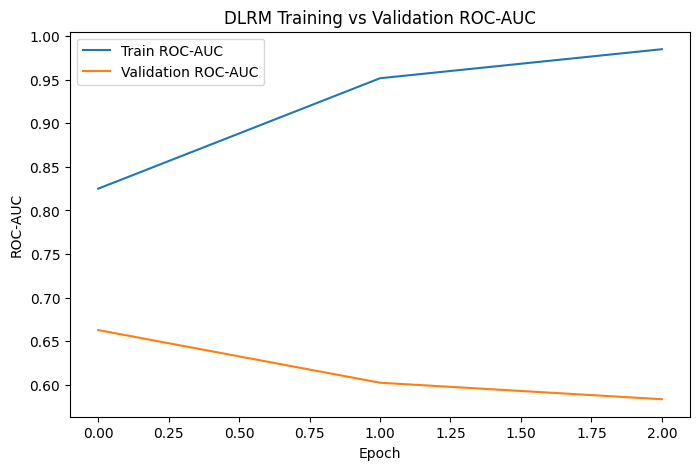

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(dlrm_history.history["roc_auc"], label="Train ROC-AUC")
plt.plot(dlrm_history.history["val_roc_auc"], label="Validation ROC-AUC")

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("DLRM Training vs Validation ROC-AUC")
plt.legend()
plt.show()

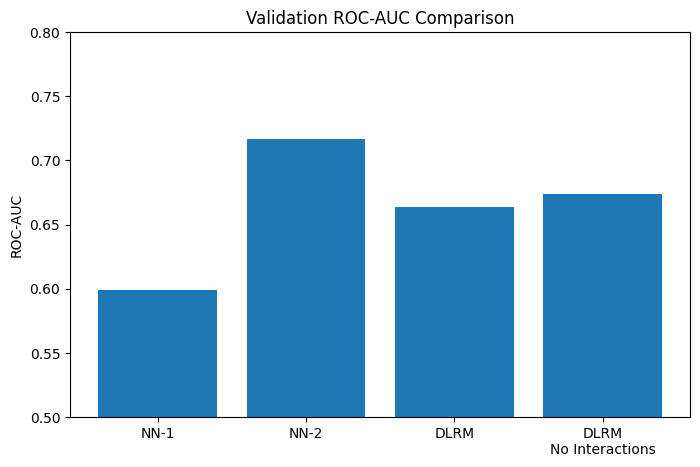

In [44]:
models = ["NN-1", "NN-2", "DLRM", "DLRM\nNo Interactions"]
roc_auc_scores = [0.599, 0.717, 0.664, 0.674]

plt.figure(figsize=(8, 5))
plt.bar(models, roc_auc_scores)

plt.ylabel("ROC-AUC")
plt.title("Validation ROC-AUC Comparison")
plt.ylim(0.5, 0.8)
plt.show()